W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
적용 폰트 : NanumBarunGothic
① 매매가격지수_아파트 파일 업로드


Saving 9-B_(월) 매매가격지수_아파트.xlsx to 9-B_(월) 매매가격지수_아파트 (1).xlsx
② 전세가격지수_아파트 파일 업로드


Saving 9-B_(월) 전세가격지수_아파트.xlsx to 9-B_(월) 전세가격지수_아파트 (1).xlsx

분석 데이터


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,월,매매가격지수,전세가격지수,월표시
0,2025-05-01,92.56,96.39,2025-05
1,2025-06-01,93.89,96.70,2025-06
2,2025-07-01,94.91,97.00,2025-07
3,2025-08-01,95.37,97.26,2025-08
4,2025-09-01,95.93,97.61,2025-09
5,2025-10-01,97.30,98.13,2025-10
6,2025-11-01,98.09,98.75,2025-11
7,2025-12-01,98.94,99.42,2025-12
8,2026-01-01,100.00,100.00,2026-01
9,2026-02-01,100.74,100.41,2026-02



상관관계 분석
피어슨 상관계수 : 0.9814


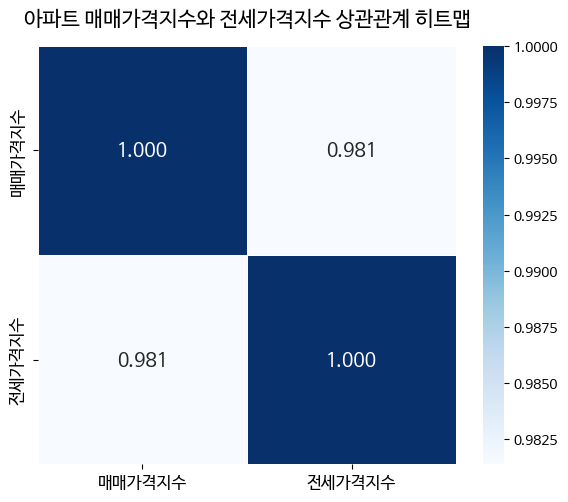

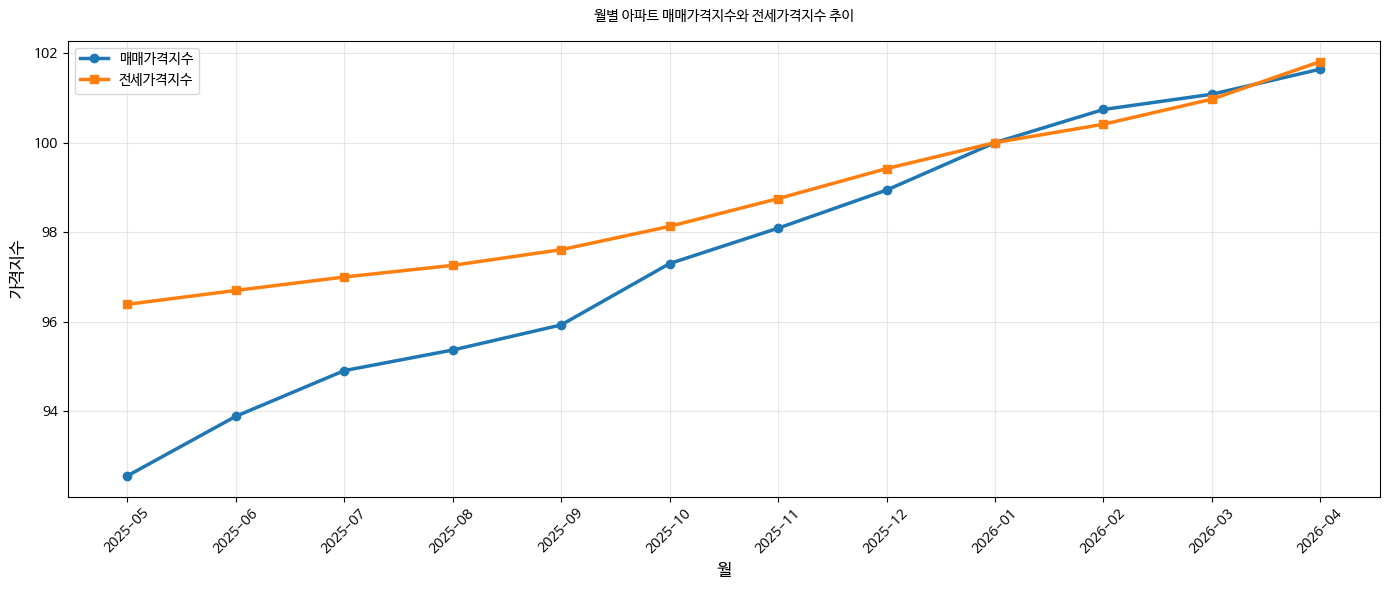

In [5]:
# ============================================================
# 아파트 매매가격지수 vs 전세가격지수 분석
# 서울 기준 / 한글 완벽 지원
# ============================================================

!apt-get -qq update
!apt-get -qq install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
from google.colab import files
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"

fm.fontManager.addfont(font_path)

font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

print("적용 폰트 :", font_name)

# ============================================================
# 파일 업로드
# ============================================================

print("="*60)
print("① 매매가격지수_아파트 파일 업로드")
print("="*60)

uploaded = files.upload()
sale_file = list(uploaded.keys())[0]

print("="*60)
print("② 전세가격지수_아파트 파일 업로드")
print("="*60)

uploaded = files.upload()
rent_file = list(uploaded.keys())[0]

# ============================================================
# 데이터 추출 함수
# ============================================================

def extract_index(file_name, value_name, region="서울"):

    raw = pd.read_excel(file_name, header=None)

    month_row = raw.iloc[0]
    type_row = raw.iloc[2]

    region_idx = raw[
        raw.iloc[:,1].astype(str).str.strip()==region
    ].index[0]

    value_row = raw.iloc[region_idx]

    result = []

    for col in range(raw.shape[1]):

        month = month_row.iloc[col]
        data_type = type_row.iloc[col]

        if str(data_type).strip() == "원자료":

            value = pd.to_numeric(
                value_row.iloc[col],
                errors="coerce"
            )

            if pd.notna(value):
                result.append([month,value])

    df = pd.DataFrame(
        result,
        columns=["월",value_name]
    )

    df["월"] = (
        df["월"]
        .astype(str)
        .str.replace("년","-",regex=False)
        .str.replace("월","",regex=False)
        .str.replace(" ","",regex=False)
    )

    df["월"] = pd.to_datetime(
        df["월"],
        format="%Y-%m"
    )

    df = df.sort_values("월").reset_index(drop=True)

    return df

# ============================================================
# 데이터 추출
# ============================================================

sale = extract_index(
    sale_file,
    "매매가격지수",
    "서울"
)

rent = extract_index(
    rent_file,
    "전세가격지수",
    "서울"
)

df = pd.merge(
    sale,
    rent,
    on="월",
    how="inner"
)

df["월표시"] = df["월"].dt.strftime("%Y-%m")

# ============================================================
# 데이터 확인
# ============================================================

print("\n분석 데이터")
display(df)

# ============================================================
# 상관관계 분석
# ============================================================

corr = df[
    ["매매가격지수","전세가격지수"]
].corr()

corr_value = corr.iloc[0,1]

print("\n" + "="*60)
print("상관관계 분석")
print("="*60)
print(f"피어슨 상관계수 : {corr_value:.4f}")
# ============================================================
# 6. 상관관계 히트맵 (일반적인 기본 스타일)
# ============================================================

import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    cbar=True,
    annot_kws={
        "size":14,
        "weight":"bold"
    }
)

plt.title(
    "아파트 매매가격지수와 전세가격지수 상관관계 히트맵",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================
# 월별 추이 그래프
# ============================================================

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(
    df["월표시"],
    df["매매가격지수"],
    marker="o",
    linewidth=2.5,
    label="매매가격지수"
)

ax.plot(
    df["월표시"],
    df["전세가격지수"],
    marker="s",
    linewidth=2.5,
    label="전세가격지수"
)

ax.set_xlabel(
    "월",
    fontsize=12,
    fontproperties=font_prop
)

ax.set_ylabel(
    "가격지수",
    fontsize=12,
    fontproperties=font_prop
)

ax.set_title(
    "월별 아파트 매매가격지수와 전세가격지수 추이",
    fontsize=16,
    fontweight="bold",
    pad=15,
    fontproperties=font_prop
)

step = max(1, len(df)//12)

ax.set_xticks(range(0,len(df),step))
ax.set_xticklabels(
    df["월표시"].iloc[::step],
    rotation=45
)

ax.grid(alpha=0.3)

ax.legend(
    prop=font_prop,
    fontsize=12
)

plt.tight_layout()
plt.show()